[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luleu96/GenAIinDD_Exercises/blob/work/Exercises/Exercise_2/T2_molGA.ipynb)

In [ ]:
!pip install rdkit
!pip install mol_ga
!pip install medchem

In [ ]:
!git clone https://github.com/luleu96/GenAIinDD_Exercises.git
%cd /content/GenAIinDD_Exercises

fatal: destination path 'GenAIinDD_Exercises' already exists and is not an empty directory.
/content/GenAIinDD_Exercises


In [2]:
import joblib
import numpy as np
import pickle as pkl
import pandas as pd
import torch

from rdkit import Chem
from rdkit.Chem import QED
from rdkit.Chem import Draw
from mol_ga import mol_libraries, default_ga
from rdkit.Chem import rdFingerprintGenerator
from typing import List, Callable

In [3]:
def run_molGA(scorer: Callable[[Chem.Mol], float], max_generations: int, offspring_size: int, start_pop: List[str]):
    # initialize start population
    start_smiles = start_pop

    # Run GA with fast parallel generation
    with joblib.Parallel(n_jobs=-1) as parallel:
        ga_results = default_ga(
            starting_population_smiles=start_smiles,
            scoring_function=lambda mols: scorer(mols),
            max_generations=max_generations,
            offspring_size=offspring_size,
            parallel=parallel,
        )
    return ga_results

In [5]:
start_pop = mol_libraries.random_zinc(1000)#'pd.read_csv('/content/GenAIinDD_Exercises/Data/egfr_pIC50.csv')['SMILES'].sample(n=1000)

In [6]:
def QED_score(mols):
  return  [QED.qed(Chem.MolFromSmiles(mol)) for mol in mols]

In [7]:
# run genetic algorithm
ga_results = run_molGA(QED_score,30,100, start_pop)

In [8]:
def draw_top_n_molecules(final_population, n):
  top_n_molecs = [Chem.MolFromSmiles(smiles[1]) for smiles in list(sorted(final_population,reverse=True)[:n])]
  top_n_scores = [str(np.round(smiles[0],5)) for smiles in list(sorted(final_population,reverse=True)[:n])]

  img = Draw.MolsToGridImage(top_n_molecs, molsPerRow=5, subImgSize=(300, 300), legends=top_n_scores)
  return img

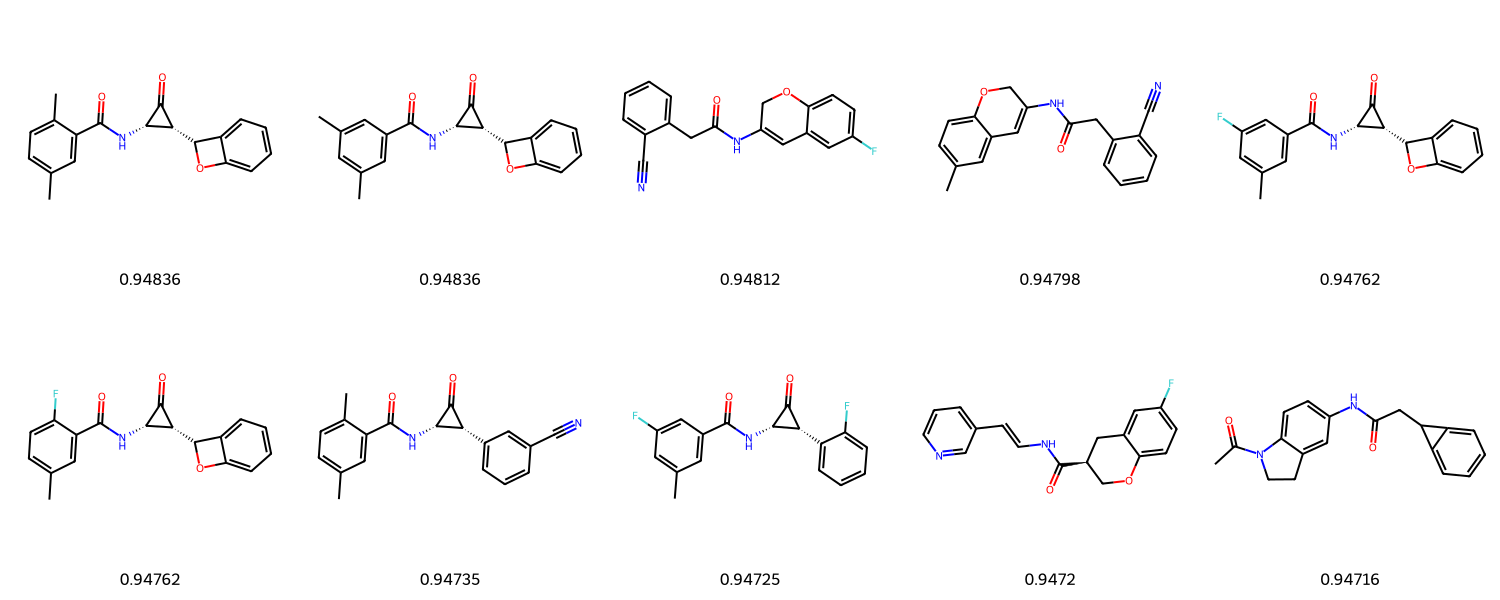

In [9]:
draw_top_n_molecules(ga_results.population, 10)

In [21]:
from utils import DeepNeuralNetworkModel

# Load trained deep neural network
input_dim = 2048
model = DeepNeuralNetworkModel(input_dim)
model.load_state_dict(torch.load('Models/best_deep.pth',weights_only=True), strict=False) 

<All keys matched successfully>

In [22]:
class DNNScorer:
  def __init__(self, model:torch.nn.Module, input_dim: int):
    self.model = model
    self.input_dim = input_dim

  def __call__(self, mols: List[torch.tensor]):
    fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=self.input_dim)
    return [self.model(torch.tensor(fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(mol)), dtype=torch.float32))[0].detach().item() for mol in mols]

In [23]:
dnn_score = DNNScorer(model,input_dim)

In [24]:
# max_generation = 10 ~ 6-11 min # sometimes gets lsot and creates this huges ass mols that take more time to compute
ga_results2 = run_molGA(dnn_score,10,100, start_pop)

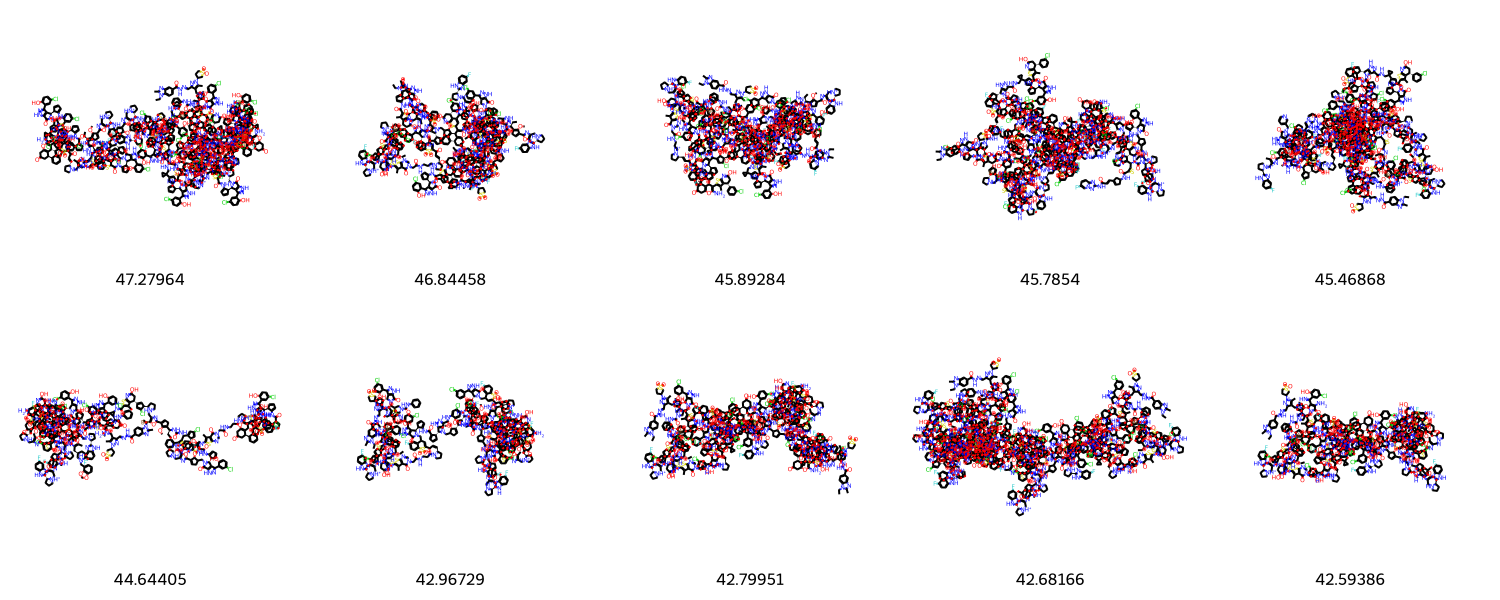

In [25]:
draw_top_n_molecules(ga_results2.population, 10) # also huge ass mols take more time here

In [26]:
def mol_ga_intermediate_pop(max_gen,f_opt,start_pop):
  pop_list = []
  population = start_pop
  for i in range(max_gen):
    pop = run_molGA(f_opt,1,100,population)
    pop_list.append(pop.population)
    population = [x[1] for x in pop.population]
  return pop_list

#intermediate_population = mol_ga_intermediate_pop(10,f_opt2,start_pop)
#draw_top_n_molecules(intermediate_population[5], 10)

In [27]:
class Combined_Scorer:
  def __init__(self, scorer1, scorer2):
    self.scorer1 = scorer1
    self.scorer2 = scorer2

  def __call__(self,mols):
    scores1 = self.scorer1(mols)
    scores2 = self.scorer2(mols)
    combined_scores = []
    if len(scores1) == len(scores2):
      for i in range(len(scores1)):
        combined_scores.append((0.5*scores1[i] + 0.5*scores2[i]))
    return combined_scores

In [28]:
combi_scorer = Combined_Scorer(QED_score,dnn_score)

In [31]:
ga_results3 = run_molGA(combi_scorer,10,100, start_pop) # ~ 1 min

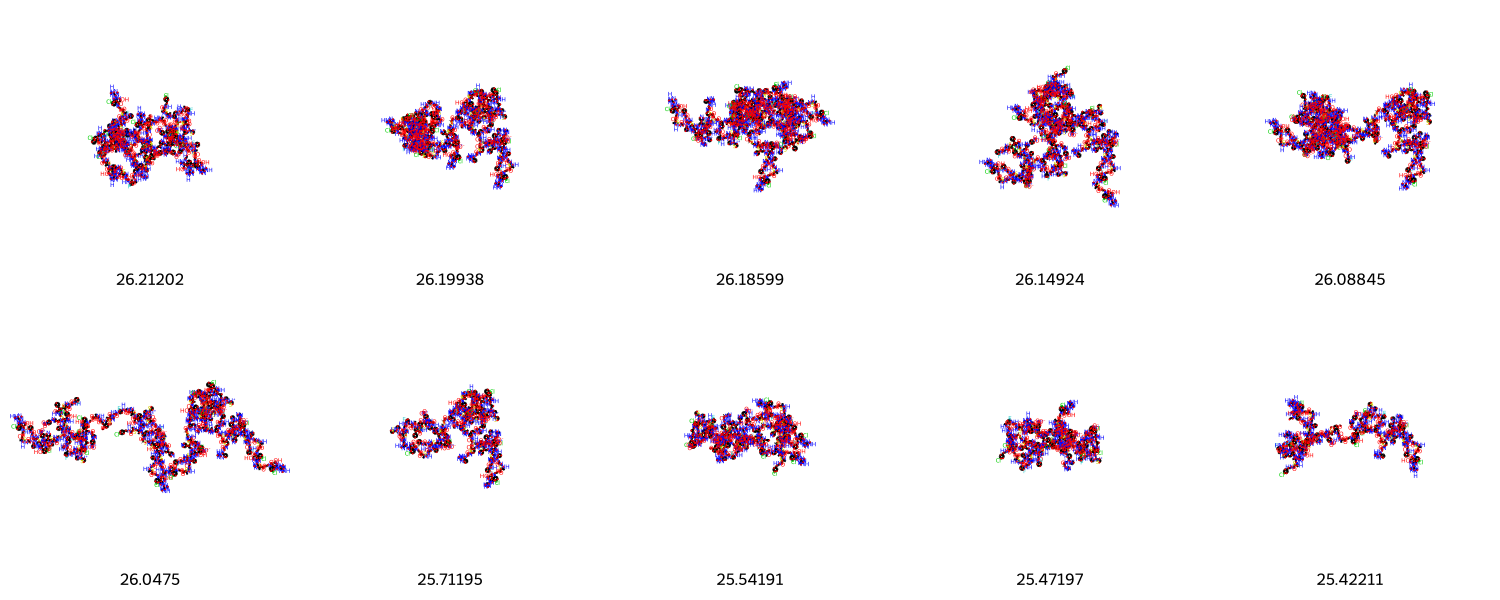

In [32]:
draw_top_n_molecules(ga_results3.population, 10)

In [33]:
from rdkit.Chem import Descriptors

class Combined_Scorer_Constraint(Combined_Scorer):
  def __call__(self,mols):
    scores1 = self.scorer1(mols)
    scores2 = self.scorer2(mols)
    for mol in range(len(mols)):
      if Descriptors.MolWt(Chem.MolFromSmiles(mols[mol])) > 500:
        scores1[mol] = float(0)
        scores2[mol] = float(0)
    combined_scores = []
    if len(scores1) == len(scores2):
      for i in range(len(scores1)):
        combined_scores.append((0.5*scores1[i] + 0.5*scores2[i]))
    return combined_scores

In [35]:
constrained = Combined_Scorer_Constraint(QED_score,dnn_score)

In [36]:
ga_results4 = run_molGA(constrained,10,100, start_pop)

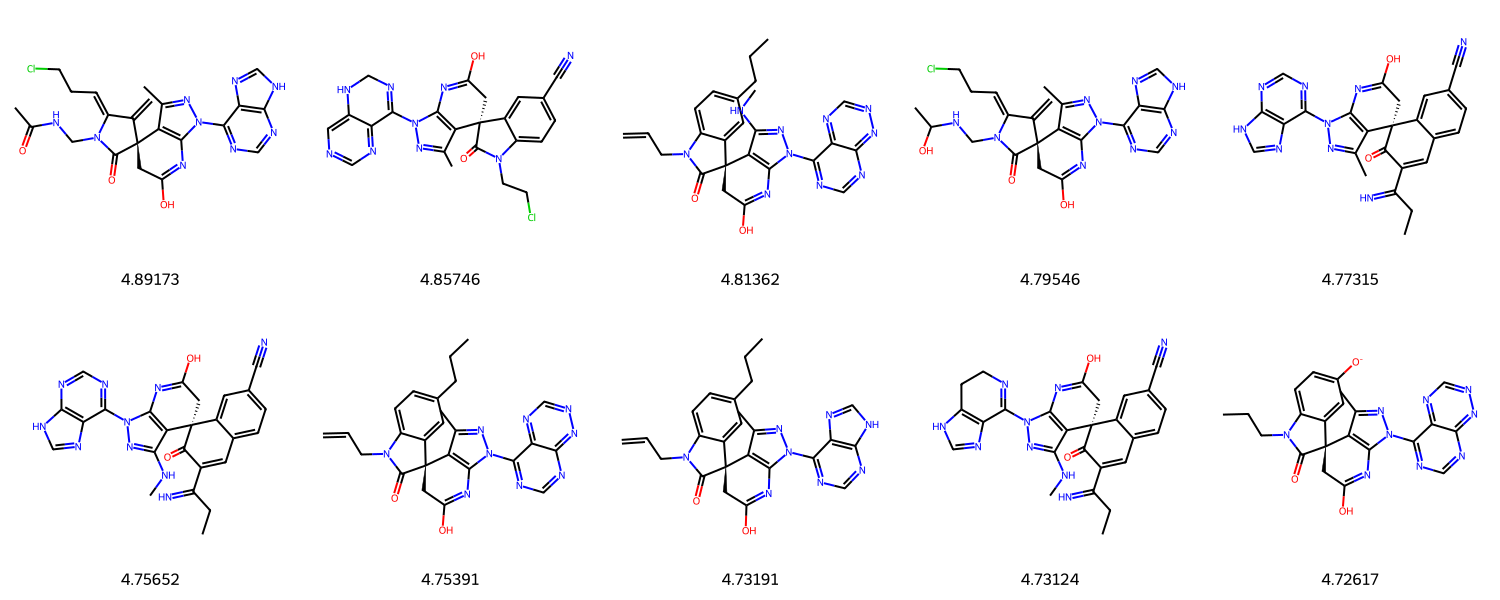

In [37]:
draw_top_n_molecules(ga_results4.population, 10)

In [38]:
import io
import requests
import medchem as mc

class EGFRPredictor:
  def __init__(self):
    r = io.BytesIO(requests.get("https://storage.googleapis.com/emmanuel-data/models/egfr_linear.pt").content)
    state_dict = torch.load(r)
    self.linear = torch.nn.Linear(2048, 1)
    self.linear.load_state_dict(state_dict)
  def predict(self, mols):
    if isinstance(mols[0], str):
      mols = [Chem.MolFromSmiles(i) for i in mols]
    fps = torch.tensor([Chem.RDKFingerprint(i) for i in mols]).float()
    with torch.no_grad():
      return self.linear(fps)[:, 0]

class EGFRScore:
  def __init__(self, predictor):
    self.predictor = predictor
  def score(self, mols):
    # TODO: incorporate more medchem heuristics
    ys = self.predictor.predict(mols)
    ro5 = 1 - torch.tensor([mc.rules.basic_rules.rule_of_five(i) for i in mols]).float()
    pains = 1 - torch.tensor(mc.functional.alert_filter(mols, ['PAINS'])).float()
    return ys / 2 ** (ro5 + pains)  # Divide the score by 2 every time a filter is unhappy

In [39]:
predictor = EGFRPredictor()

C:\Users\lucas\AppData\Local\Temp\ipykernel_9128\1528376307.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(r)


In [41]:
EGFR_scorer = EGFRScore(predictor)

In [42]:
ga_results5 = run_molGA(EGFR_scorer.score,30,100, start_pop) # ~ 2 min

c:\Users\lucas\anaconda3\envs\aidd\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


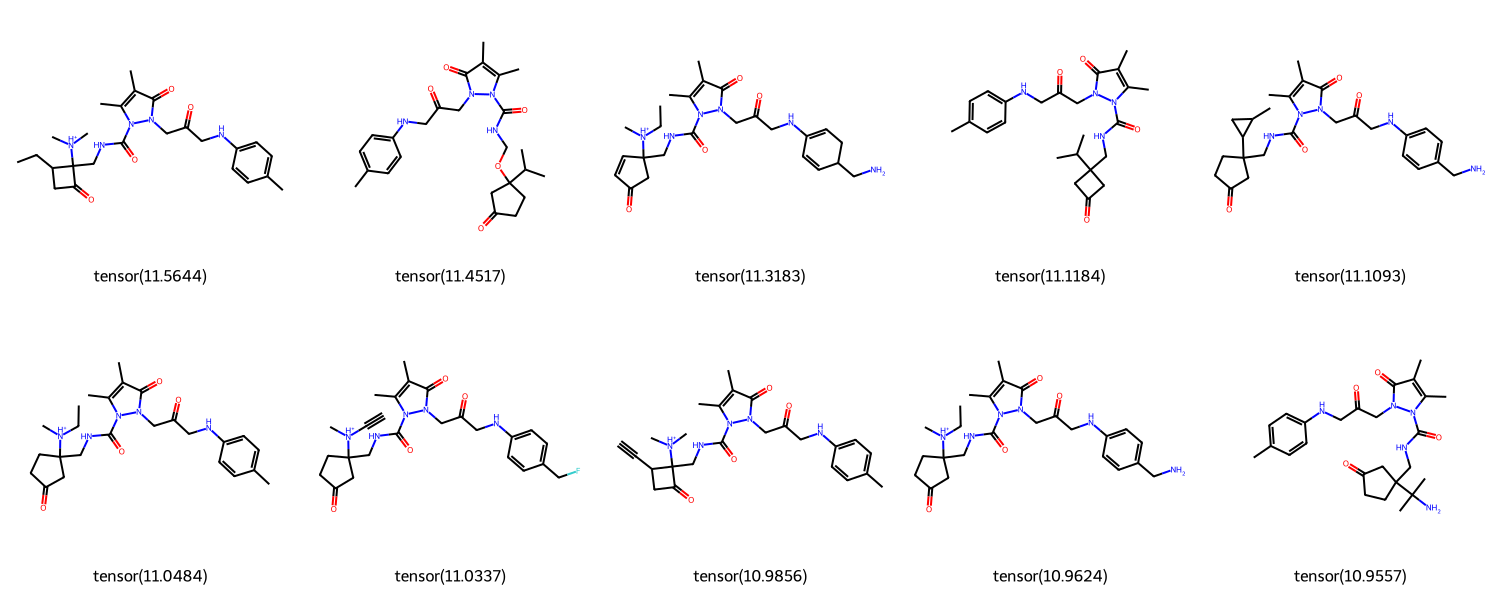

In [43]:
draw_top_n_molecules(ga_results5.population, 10)